[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nisheshgogia/vorithm-interview-questions-solutions/blob/main/Python/math/math.ipynb)

# Maths


# 1. Reverse a Number
# Difficulty: 🟡 MediumProblem Statement:

Given a signed 32-bit integer x, return x with its digits reversed. If reversing x causes the value to go outside the signed 32-bit integer range [-2³¹, 2³¹ - 1], then return 0.Assume the environment does not allow you to store 64-bit integers (signed or unsigned).

```
Example 1:
Input: x = 123
Output: 321
```
```
Example 2:
Input: x = -123
Output: -321
Explanation: Negative sign is preserved
```

```
Example 3:
Input: x = 120
Output: 21
Explanation: Trailing zeros are removed
```
```
Example 4:

Input: x = 1534236469
Output: 0
Explanation: Reversed is 9646324351 which exceeds 2³¹ - 1 = 2147483647Constraints:

-2³¹ ≤ x ≤ 2³¹ - 1gm

In [ ]:
#Brute Force Approach (Convert to String, Reverse, Convert Back)
def reverse_brute(x):
    # Handle sign
    sign = -1 if x < 0 else 1
    x = abs(x)

    # Convert to string, reverse, convert back
    reversed_str = str(x)[::-1]
    result = sign * int(reversed_str)

    # Check overflow (32-bit signed integer range)
    INT_MAX = 2**31 - 1  # 2147483647
    INT_MIN = -2**31     # -2147483648

    if result > INT_MAX or result < INT_MIN:
        return 0

    return result

print(reverse_brute(123))         # Output: 321
print(reverse_brute(-123))        # Output: -321
print(reverse_brute(120))         # Output: 21
print(reverse_brute(1534236469))  # Output: 0

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(d)   : where d = number of digits in x
#                  str() conversion: O(d) to generate string
#                  string reversal [::-1]: O(d) to reverse
#                  int() conversion: O(d) to parse
# avg   → O(d)   : all operations linear in number of digits
#                  total = O(d) + O(d) + O(d) = O(d)
#                  d = log₁₀(|x|) + 1
# worst → O(d)   : large x with many digits still O(d) operations
# space → O(d)   : str(x) creates string of d characters
#                  reversed_str stores d characters

#best time complexity    - O(d) where d = log₁₀(|x|) + 1
#average time complexity - O(d)
#worst time complexity   - O(d)
#space complexity        - O(d)



321
-321
21
0


In [ ]:
#Optimized Approach (Mathematical Digit Extraction)
def reverse_optimized(x):
    # Handle sign
    sign = -1 if x < 0 else 1
    x = abs(x)

    result = 0
    INT_MAX = 2**31 - 1  # 2147483647

    while x != 0:
        digit = x % 10  # Extract last digit
        x //= 10        # Remove last digit

        # Check for overflow BEFORE multiplication
        # If result > INT_MAX // 10, then result * 10 will overflow
        # If result == INT_MAX // 10, check if digit would cause overflow
        if result > INT_MAX // 10:
            return 0
        if result == INT_MAX // 10 and digit > 7:  # Last digit of INT_MAX is 7
            return 0

        result = result * 10 + digit

    return sign * result

print(reverse_optimized(123))         # Output: 321
print(reverse_optimized(-123))        # Output: -321
print(reverse_optimized(120))         # Output: 21
print(reverse_optimized(1534236469))  # Output: 0

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(d)   : even single digit requires one loop iteration
#                  but d=1 so O(1)
# avg   → O(d)   : while loop runs d times (once per digit)
#                  each iteration: % and // operations = O(1)
#                  total = d × O(1) = O(d)
# worst → O(d)   : number with d digits processed in d iterations
#                  d = ⌊log₁₀(|x|)⌋ + 1
# space → O(1)   : only result, digit variables, no strings or arrays

# WHY OVERFLOW CHECK IS COMPLEX:
# We can't just reverse and check because result * 10 might overflow
# Must check BEFORE multiplying: result > INT_MAX / 10
# Edge case: when result == INT_MAX / 10, next digit must be ≤ 7
# (because INT_MAX = 2147483647, last digit is 7)

# VISUALIZATION for x=123:
# Iteration 1: digit=3, x=12, result=0*10+3=3
# Iteration 2: digit=2, x=1, result=3*10+2=32
# Iteration 3: digit=1, x=0, result=32*10+1=321
# Result: 321 ✓

#best time complexity    - O(d)
#average time complexity - O(d)
#worst time complexity   - O(d)
#space complexity        - O(1)

321
-321
21
0


## 2. Check if a Number is Prime
**Difficulty: 🟢 Low**

**Problem Statement:**
Given an integer n, return true if n is a prime number, and false otherwise.

A prime number is a natural number greater than 1 that has no positive divisors other than 1 and itself.
```
**Example 1:**
Input: n = 2
Output: true
Explanation: 2 is the smallest prime number
```
```
**Example 2:**
Input: n = 17
Output: true
Explanation: 17 has no divisors other than 1 and 17
```
```
**Example 3:**
Input: n = 1
Output: false
Explanation: 1 is not considered prime
```
```
**Example 4:**
Input: n = 4
Output: false
Explanation: 4 = 2 × 2, has divisor 2

In [ ]:
#Brute Force Approach (Check All Numbers from 2 to n-1)
def is_prime_brute(n):
    if n <= 1:
        return False

    if n == 2:
        return True

    # Check if any number from 2 to n-1 divides n
    for i in range(2, n):
        if n % i == 0:
            return False

    return True

print(is_prime_brute(2))   # Output: True
print(is_prime_brute(17))  # Output: True
print(is_prime_brute(1))   # Output: False
print(is_prime_brute(4))   # Output: False

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(1)   : n ≤ 2 returns immediately
#                  or n is even (divisible by 2) → found in first iteration
# avg   → O(n)   : for prime n, must check all numbers from 2 to n-1
#                  average: ~n/2 iterations before confirming prime
# worst → O(n)   : n is prime → loop runs full n-2 iterations
#                  example: n=97 requires 95 checks
# space → O(1)   : only loop variable i, no extra structures

#best time complexity    - O(1)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(1)


True
True
False
False


In [ ]:
#Optimized Approach (Check Only Up to √n)
def is_prime_optimized(n):
    if n <= 1:
        return False

    if n <= 3:
        return True  # 2 and 3 are prime

    # Eliminate multiples of 2 and 3
    if n % 2 == 0 or n % 3 == 0:
        return False

    # Check for divisors up to √n
    # All primes > 3 are of form 6k±1
    i = 5
    while i * i <= n:
        if n % i == 0 or n % (i + 2) == 0:
            return False
        i += 6

    return True

print(is_prime_optimized(7))
print(is_prime_optimized(10))
print(is_prime_optimized(29))

True
False
True


In [ ]:
# Simpler version (check all odd numbers up to √n)
def is_prime_simple(n):
    if n <= 1:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False

    # Check odd divisors from 3 to √n
    i = 3
    while i * i <= n:
        if n % i == 0:
            return False
        i += 2

    return True

print(is_prime_optimized(2))   # Output: True
print(is_prime_optimized(17))  # Output: True
print(is_prime_simple(97))     # Output: True

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(1)   : n ≤ 3 or divisible by 2 or 3 → immediate return
# avg   → O(√n)  : loop runs from 5 to √n in steps of 6
#                  iterations ≈ √n / 6
# worst → O(√n)  : n is prime → must check all i where i² ≤ n
#                  loop iterations = √n / 6 (optimized) or √n / 2 (simple)
#                  example: n=97 → √97 ≈ 10, only ~10 checks vs 95!
# space → O(1)   : only variable i, no extra memory

# WHY √n IS SUFFICIENT:
# If n has a divisor d where d > √n, then n/d < √n
# So we would have already found the smaller divisor n/d
# Example: 36 = 6 × 6, if we check up to 6, we find it
#          36 = 4 × 9, when checking 4 (< 6), we find it

# WHY 6k±1 OPTIMIZATION WORKS:
# All integers can be expressed as 6k, 6k+1, 6k+2, 6k+3, 6k+4, 6k+5
# 6k, 6k+2, 6k+4 are divisible by 2
# 6k+3 is divisible by 3
# Only 6k+1 and 6k+5 (i.e., 6k-1) can be prime
# So we check i and i+2 starting from i=5 (6×1-1)

#best time complexity    - O(1)
#average time complexity - O(√n)
#worst time complexity   - O(√n)
#space complexity        - O(1)


True
True
True


## 3. Check if a Number is Armstrong
**Difficulty: 🟢 Low**

**Problem Statement:**
Given an integer n, return true if it is an Armstrong number (also called narcissistic number), otherwise return false.

An Armstrong number in base 10 is a number that is equal to the sum of its own digits each raised to the power of the number of digits.
```
**Example 1:**
Input: n = 153
Output: true
Explanation: 153 has 3 digits
1³ + 5³ + 3³ = 1 + 125 + 27 = 153 ✓
```
```
**Example 2:**
Input: n = 370
Output: true
Explanation: 3³ + 7³ + 0³ = 27 + 343 + 0 = 370 ✓
```
```
**Example 3:**
Input: n = 9
Output: true
Explanation: 9¹ = 9 ✓ (single digit Armstrong numbers are themselves)
```
```
**Example 4:**
Input: n = 123
Output: false
Explanation: 1³ + 2³ + 3³ = 1 + 8 + 27 = 36 ≠ 123

In [ ]:
#Brute Force Approach (Convert to String, Count Digits)
def is_armstrong_brute(n):
    # Convert to string to count digits
    str_n = str(n)
    num_digits = len(str_n)

    # Calculate sum of digits raised to power of num_digits
    total = 0
    for digit_char in str_n:
        digit = int(digit_char)
        total += digit ** num_digits

    return total == n

print(is_armstrong_brute(153))  # Output: True
print(is_armstrong_brute(370))  # Output: True
print(is_armstrong_brute(9))    # Output: True
print(is_armstrong_brute(123))  # Output: False

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(d)   : where d = number of digits
#                  str() conversion: O(d)
#                  loop over d digits: O(d)
#                  each pow operation: O(1) for small exponents
# avg   → O(d)   : str conversion + loop + power operations
#                  d = log₁₀(n) + 1
#                  total = O(d) + O(d) = O(d)
# worst → O(d)   : large n with many digits still O(d) operations
# space → O(d)   : str_n stores d characters

#best time complexity    - O(d) where d = log₁₀(n) + 1
#average time complexity - O(d)
#worst time complexity   - O(d)
#space complexity        - O(d)


True
True
True
False


In [ ]:
#Optimized Approach (Mathematical Digit Extraction)
def is_armstrong_optimized(n):
    if n < 0:
        return False

    # Count number of digits
    temp = n
    num_digits = 0
    while temp > 0:
        num_digits += 1
        temp //= 10

    # Calculate sum of digits raised to power
    temp = n
    total = 0
    while temp > 0:
        digit = temp % 10
        total += digit ** num_digits
        temp //= 10

    return total == n

print(is_armstrong_optimized(153))
print(is_armstrong_optimized(123))

True
False


In [ ]:
# One-pass version (more concise)
def is_armstrong_one_pass(n):
    if n < 0:
        return False

    # Store digits first
    digits = []
    temp = n
    while temp > 0:
        digits.append(temp % 10)
        temp //= 10

    # Calculate sum
    num_digits = len(digits)
    total = sum(d ** num_digits for d in digits)

    return total == n

print(is_armstrong_optimized(153))    # Output: True
print(is_armstrong_one_pass(370))     # Output: True

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(d)   : single digit n → num_digits=1, one iteration each loop
# avg   → O(d)   : first while loop: d iterations to count digits
#                  second while loop: d iterations to compute sum
#                  total = 2d = O(d)
# worst → O(d)   : large n → both loops run d times
#                  d = ⌊log₁₀(n)⌋ + 1
# space → O(1)   : only temp, total, digit variables
#                  (one-pass version uses O(d) for digits array)

# VISUALIZATION for n=153:
# Count digits: temp=153→15→1→0, num_digits=3
# Calculate sum:
#   temp=153: digit=3, total=0+27=27, temp=15
#   temp=15:  digit=5, total=27+125=152, temp=1
#   temp=1:   digit=1, total=152+1=153, temp=0
# Result: 153 == 153 ✓

#best time complexity    - O(d)
#average time complexity - O(d)
#worst time complexity   - O(d)
#space complexity        - O(1)


True
True


## 4. Count the Number of Digits
**Difficulty: 🟢 Low**

**Problem Statement:**
Given a non-negative integer num, return the number of digits it contains.

**Example 1:**
```
Input: num = 12345
Output: 5
```

**Example 2:**
```
Input: num = 0
Output: 1
Explanation: Zero has one digit
```

**Example 3:**
```
Input: num = 100
Output: 3

In [ ]:
#Brute Force Approach (Convert to String)
def count_digits_brute(num):
    return len(str(num))

print(count_digits_brute(12345))  # Output: 5
print(count_digits_brute(0))      # Output: 1
print(count_digits_brute(100))    # Output: 3

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(d)   : str() conversion generates string of d digits
#                  len() counts in O(d) (though often optimized to O(1))
# avg   → O(d)   : converting number to string: O(d) where d = digits
#                  d = log₁₀(num) + 1
# worst → O(d)   : large num with many digits still O(d)
# space → O(d)   : str(num) creates string of d characters

#best time complexity    - O(d)
#average time complexity - O(d)
#worst time complexity   - O(d)
#space complexity        - O(d)

5
1
3


In [ ]:
#Optimized Approach 1 (Iterative Division)
def count_digits_iterative(num):
    if num == 0:
        return 1

    count = 0
    while num > 0:
        count += 1
        num //= 10

    return count

print(count_digits_iterative(12345))  # Output: 5
print(count_digits_iterative(0))      # Output: 1

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(1)   : num=0 returns immediately
#                  single digit returns after 1 iteration
# avg   → O(d)   : while loop runs d times (once per digit)
#                  each iteration: one division O(1)
#                  total = d × O(1) = O(d)
# worst → O(d)   : large num → loop runs d times where d = ⌊log₁₀(num)⌋ + 1
# space → O(1)   : only count variable, no extra structures

# VISUALIZATION for num=12345:
# Iteration 1: count=1, num=1234
# Iteration 2: count=2, num=123
# Iteration 3: count=3, num=12
# Iteration 4: count=4, num=1
# Iteration 5: count=5, num=0
# Result: 5 ✓

#best time complexity    - O(1)
#average time complexity - O(d)
#worst time complexity   - O(d)
#space complexity        - O(1)

5
1


In [ ]:
#Optimized Approach 2 (Logarithm - O(1) Mathematical)
import math

def count_digits_log(num):
    if num == 0:
        return 1

    # Number of digits = floor(log₁₀(num)) + 1
    return math.floor(math.log10(num)) + 1

print(count_digits_log(12345))  # Output: 5
print(count_digits_log(100))    # Output: 3

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(1)   : log10() is a constant-time mathematical operation
#                  regardless of num's value
# avg   → O(1)   : floor() and arithmetic are O(1)
#                  total = O(1) + O(1) + O(1) = O(1)
# worst → O(1)   : even num=10^100 still O(1) computation
# space → O(1)   : no extra memory used

# WHY IT WORKS:
# Number of digits in n = ⌊log₁₀(n)⌋ + 1
# Examples:
# - n=100: log₁₀(100)=2, floor(2)+1=3 digits ✓
# - n=999: log₁₀(999)≈2.999, floor(2.999)+1=3 digits ✓
# - n=1000: log₁₀(1000)=3, floor(3)+1=4 digits ✓

# LIMITATION: Floating-point precision issues for very large numbers
# For most practical purposes, works perfectly

#best time complexity    - O(1)
#average time complexity - O(1)
#worst time complexity   - O(1)
#space complexity        - O(1)

5
3


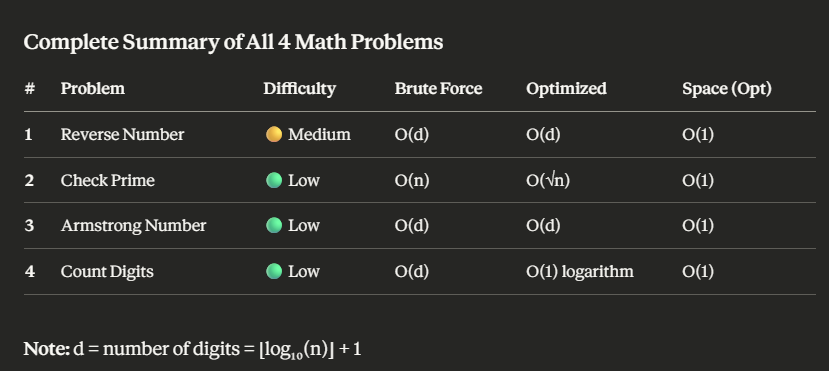